# Model Training

This notebook presents the full machine learning workflow developed for the public transportation delay classification task.

The process includes the following main stages:

1. **Data Preparation and Transformation** - Importing the training, validation, and test datasets, followed by preprocessing, feature engineering, probability-based features, handling missing values, encoding categorical variables, and preparing the data for modeling.
   
2. **Baseline Models** - Evaluation of initial baseline approaches, including simple regression and classification benchmarks, in order to establish reference performance levels.
 
3. **Model Training and Comparison** - Training and evaluation of multiple classification models, with comparison based on Accuracy, F1-scores, Recall, confusion matrices, and overfitting analysis.

4. **Model Tuning and Optimization** - Hyperparameter tuning and threshold optimization for the selected model in order to improve performance, especially for the underrepresented early and on_time classes.

5. **Final Evaluation and Feature Importance Analysis** - Final evaluation on the unseen test dataset, followed by SHAP-based feature importance analysis to better understand the model behavior and the contribution of the different features to the predictions.

## 1. Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                              classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src.data_cleaning_and_manipulations import drop_unnecessary_columns, manipulate_df_process
from src.model_training import evaluate_model, evaluate_model_pred, check_overfitting, check_overfitting_full
import warnings
warnings.filterwarnings('ignore')

## 2. Load data

In [24]:
train_df = pd.read_csv(r'../data/model_datasets/train_df.csv', encoding='utf-8-sig')
val_df = pd.read_csv(r'../data/model_datasets/val_df.csv', encoding='utf-8-sig')
test_df  = pd.read_csv(r'../data/model_datasets/test_df.csv', encoding='utf-8-sig')

### 2.1. Transform dataframes

Pass the dataframes through the pipelines functions made in the notebool "Data cleaning & manipulation" to ensure all the DFs are going through the same preprocessing, and data leakage is prevented

In [25]:
### First - Train DF

train_df, te = manipulate_df_process(
    train_df,
    train=True
)

### Second - Validation DF
val_df = manipulate_df_process(
    val_df,
    ref_df=train_df,
    train=False,
    te=te
)

### Third - Test DF

test_df = manipulate_df_process(
    test_df,
    ref_df=train_df,
    train=False,
    te=te
)

### Lastly - drop unnecessary features
train_df = drop_unnecessary_columns(train_df)
val_df = drop_unnecessary_columns(val_df)
test_df = drop_unnecessary_columns(test_df)

In [26]:
# Define features and target
best_features = ['is_night', 'arrival_hour', 'departure_hour', 'Avg_Passengers_Per_Bus',
                 'agency_linenum_dir_alter_encoded', 'full_hour', 'agency_name_encoded',
                 'Total_Passengers', 'passengers_x_peak', 'day_encoded', 'time_of_day_encoded',
                 'perc_within_pt_route_peak', 'rainfall_mm',
                 'origin_station_encoded', 'route_length', 'night_x_long_route',
                 'destination_station_encoded', 'number_of_stops', 'origin_city_encoded',
                 'stops_x_passengers', 'destination_city_encoded', 'length_in_buffer_m',
                 'speed_kmh_planned', 'perc_within_pt_route', 'curvity', 'route_id','early_by_hour_length_proba','route_length_bin_encoded']

target_col = 'delay_cat'
cols_to_exclude = [target_col, 'duration_difference_min']

X_train = train_df.drop(columns=cols_to_exclude, errors='ignore')
y_train = train_df[target_col]

X_val = val_df.drop(columns=cols_to_exclude, errors='ignore')
y_val = val_df[target_col]

X_test = test_df.drop(columns=cols_to_exclude, errors='ignore')
y_test = test_df[target_col]

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (63276, 32)
X_val:   (13544, 32)
X_test:  (13573, 32)


## 3. Baseline Models

### 3.1. Initial regression models

The first modeling direction explored in this project was a regression approach, where the goal was to directly predict the continuous target variable duration_difference_min.

A baseline Random Forest Regressor was trained and evaluated on the validation dataset in order to assess the feasibility of predicting the exact delay or early duration in minutes.

While the model captured some general patterns in the data, the overall predictive performance was not sufficiently strong, especially considering the natural variability and noise in public transportation trip behavior.

Based on these results, the project later shifted toward a classification-based approach (delay_cat), which aimed to predict operational states such as early, on-time, and delay instead of exact minute differences.

In [11]:
# =========================================================
# Initial Regression Models: Random Forest + XGBoost
# =========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

target_col = "duration_difference_min"

# Define X / y
X_train = train_df.drop(columns=[target_col, "delay_cat"], errors="ignore")
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col, "delay_cat"], errors="ignore")
y_val = val_df[target_col]

# Keep only numeric columns
X_train = X_train.select_dtypes(include="number")
X_val = X_val[X_train.columns]

results = []

# -----------------------------
# Random Forest Regressor
# -----------------------------
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_val)

results.append({
    "Model": "Random Forest Regressor",
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_rf)),
    "MAE": mean_absolute_error(y_val, y_pred_rf),
    "R2": r2_score(y_val, y_pred_rf)
})

# -----------------------------
# XGBoost Regressor
# -----------------------------
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

y_pred_xgb = xgb_reg.predict(X_val)

results.append({
    "Model": "XGBoost Regressor",
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred_xgb)),
    "MAE": mean_absolute_error(y_val, y_pred_xgb),
    "R2": r2_score(y_val, y_pred_xgb)
})

# Results table
regression_results = pd.DataFrame(results)

regression_results

,Model,RMSE,MAE,R2
0,Random Forest Regressor,14.392968,8.623486,0.385704
1,XGBoost Regressor,13.625588,8.077313,0.449462


### 3.2. Classifier baseline model

Following the relatively weak performance of the regression-based models, the next modeling direction explored was a classification approach.
Instead of predicting the exact delay or early duration in minutes, the target variable was transformed into operational categories (early, on_time, and delay). This approach aimed to reduce the impact of noise and variability in exact trip durations while focusing on more practical operational states.
As an initial baseline for the classification task, a simple rule-based model was created. The model predicts the most frequent delay category for each bus line, based only on historical observations from the training dataset. In practice, for every validation observation, the model assigns the category that appeared most frequently for that specific line during training.
This baseline provides a simple reference point for evaluating whether more advanced machine learning models are able to capture additional patterns beyond the historical dominant behavior of each route.

=== Baseline - Most Frequent Class by Line ===
Accuracy:         0.738
F1 Macro:         0.447
F1 Delay:         0.842
F1 Early:         0.101
F1 On Time:       0.398
Recall Delay:     0.940
Recall Early:     0.055
Recall On Time:   0.302

              precision    recall  f1-score   support

       delay       0.76      0.94      0.84      9553
       early       0.59      0.06      0.10       740
     on_time       0.58      0.30      0.40      3251

    accuracy                           0.74     13544
   macro avg       0.64      0.43      0.45     13544
weighted avg       0.71      0.74      0.69     13544



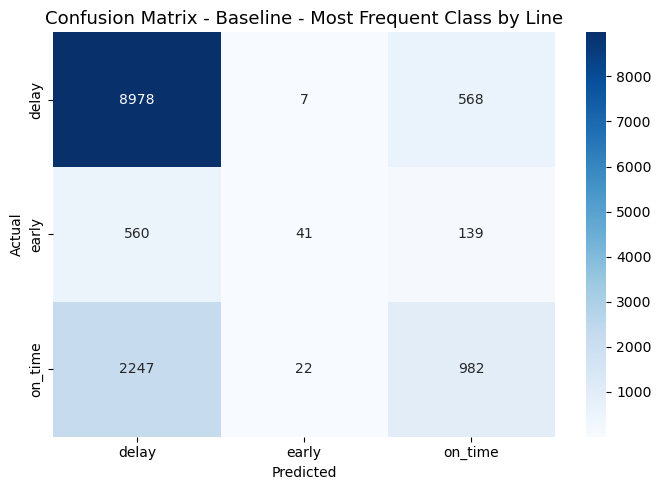

Accuracy:
0.7384

Classification Report:
              precision    recall  f1-score   support

       delay       0.76      0.94      0.84      9553
       early       0.59      0.06      0.10       740
     on_time       0.58      0.30      0.40      3251

    accuracy                           0.74     13544
   macro avg       0.64      0.43      0.45     13544
weighted avg       0.71      0.74      0.69     13544



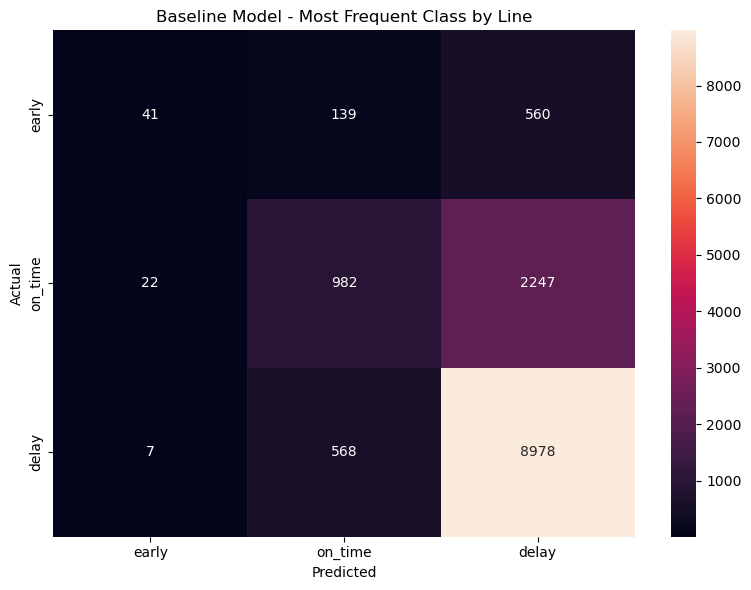

In [27]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

results = []

target_col = "delay_cat"
group_cols = ["agency_linenum_dir_alter_encoded"]

# =========================================================
# Build baseline table from TRAIN only
# Most frequent class by line
# =========================================================

baseline_table = (
    train_df
    .groupby(group_cols)[target_col]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={target_col: "baseline_prediction"})
)

# Global fallback
global_class = train_df[target_col].mode()[0]

# =========================================================
# Apply to validation
# =========================================================

val_pred_df = val_df.merge(
    baseline_table,
    on=group_cols,
    how="left"
)

val_pred_df["baseline_prediction"] = (
    val_pred_df["baseline_prediction"]
    .fillna(global_class)
)

# =========================================================
# Evaluate
# =========================================================

y_true = val_pred_df[target_col]
y_pred = val_pred_df["baseline_prediction"]

# =========================================================
# Add baseline model results to results list
# =========================================================

results.append(
    evaluate_model_pred(
        y_true=y_true,
        y_pred=y_pred,
        model_name="Baseline - Most Frequent Class by Line"
    )
)

print("Accuracy:")
print(round(accuracy_score(y_true, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# =========================================================
# Confusion Matrix
# =========================================================

labels = ["early", "on_time", "delay"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Model - Most Frequent Class by Line")

plt.tight_layout()
plt.show()

Following the relatively weak performance of the regression-based models, the next modeling direction explored was a classification approach.

Instead of predicting the exact delay or early duration in minutes, the target variable was transformed into operational categories (early, on_time, and delay). This approach aimed to reduce the impact of noise and variability in exact trip durations while focusing on more practical operational states.

As an initial baseline for the classification task, a simple rule-based model was created. The model predicts the most frequent delay category for each bus line, based only on historical observations from the training dataset. In practice, for every validation observation, the model assigns the category that appeared most frequently for that specific line during training.

This baseline provides a simple reference point for evaluating whether more advanced machine learning models are able to capture additional patterns beyond the historical dominant behavior of each route.

The classification approach also aligns better with the main modeling challenges observed in the dataset. The baseline results show that the model performs relatively well in identifying delays, which are the most common observations in the data. However, the real challenge lies in correctly identifying on_time and especially early trips, which are significantly less frequent and therefore more difficult to model accurately.

Based on these observations, the remainder of the project focuses on developing and improving classification-based models.

## 4. Classifiers models comparison

In [29]:
### Split the train and val again before running classification
target_col = "delay_cat"

X_train = train_df.drop(columns=["delay_cat", "duration_difference_min"], errors="ignore")
y_train = train_df[target_col]

X_val = val_df.drop(columns=["delay_cat", "duration_difference_min"], errors="ignore")
y_val = val_df[target_col]

# numeric only
X_train = X_train.select_dtypes(include="number")
X_val = X_val[X_train.columns]

### 4.1. Logistic Regression

=== Logistic Regression ===
Accuracy:         0.592
F1 Macro:         0.475
F1 Delay:         0.718
F1 Early:         0.203
F1 On Time:       0.503
Recall Delay:     0.598
Recall Early:     0.465
Recall On Time:   0.602

              precision    recall  f1-score   support

       delay       0.90      0.60      0.72      9553
       early       0.13      0.46      0.20       740
     on_time       0.43      0.60      0.50      3251

    accuracy                           0.59     13544
   macro avg       0.49      0.55      0.47     13544
weighted avg       0.74      0.59      0.64     13544



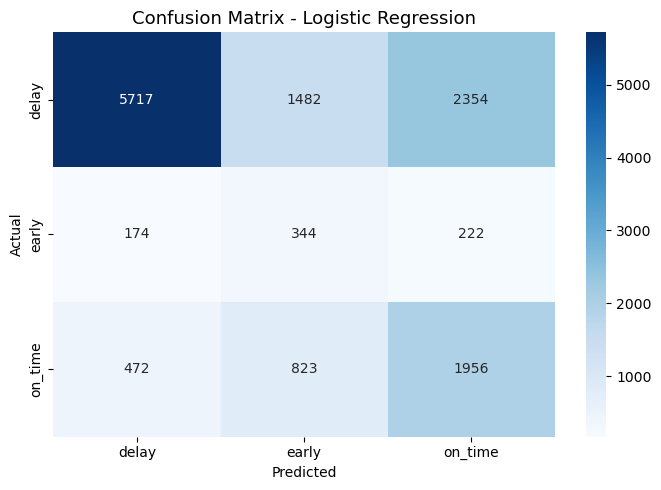

In [30]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
results.append(evaluate_model(lr, X_val, y_val, 'Logistic Regression'))

### 4.2. Random Forest

=== Random Forest ===
Accuracy:         0.785
F1 Macro:         0.639
F1 Delay:         0.866
F1 Early:         0.415
F1 On Time:       0.636
Recall Delay:     0.859
Recall Early:     0.418
Recall On Time:   0.648

              precision    recall  f1-score   support

       delay       0.87      0.86      0.87      9553
       early       0.41      0.42      0.42       740
     on_time       0.62      0.65      0.64      3251

    accuracy                           0.78     13544
   macro avg       0.64      0.64      0.64     13544
weighted avg       0.79      0.78      0.79     13544



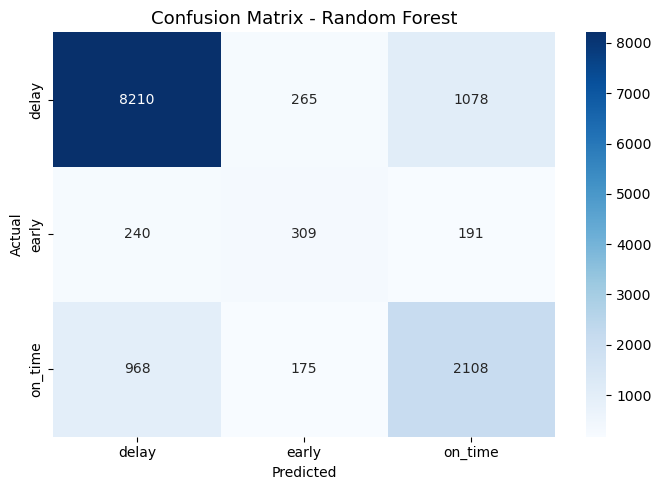

In [31]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_val, y_val, 'Random Forest'))

### 4.3. XGBoost

=== XGBoost ===
Accuracy:         0.833
F1 Macro:         0.685
F1 Delay:         0.899
F1 Early:         0.471
F1 On Time:       0.686
Recall Delay:     0.929
Recall Early:     0.347
Recall On Time:   0.661

              precision    recall  f1-score   support

       delay       0.87      0.93      0.90      9553
       early       0.73      0.35      0.47       740
     on_time       0.71      0.66      0.69      3251

    accuracy                           0.83     13544
   macro avg       0.77      0.65      0.69     13544
weighted avg       0.83      0.83      0.82     13544



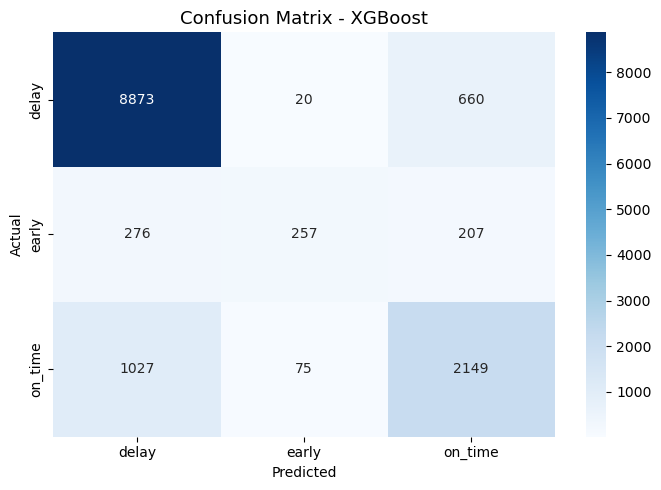

In [32]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Create copies only for XGBoost
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

# Convert category columns to int only in XGBoost copies
for df_xgb in [X_train_xgb, X_val_xgb]:
    for col in df_xgb.select_dtypes(include="category").columns:
        df_xgb[col] = df_xgb[col].astype(int)

# Encode target only for XGBoost
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)

# Train model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train_xgb, y_train_enc)

# Predict
y_pred_xgb = le.inverse_transform(
    xgb.predict(X_val_xgb)
)

# Evaluate
results.append(
    evaluate_model_pred(
        y_val,
        y_pred_xgb,
        "XGBoost"
    )
)

### 4.4. LightGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4307
[LightGBM] [Info] Number of data points in the train set: 63276, number of used features: 32
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

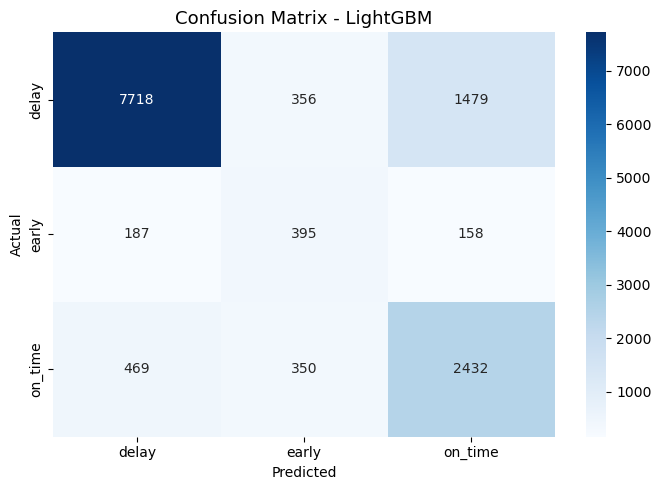

In [33]:
#!pip install lightgbm

from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      random_state=42, class_weight='balanced', n_jobs=-1)
lgbm.fit(X_train, y_train)
results.append(evaluate_model(lgbm, X_val, y_val, 'LightGBM'))

## 5. Model Comparison Summary

In [34]:
# ===== Models metrics ====

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1_Delay_Early', ascending=False)
print(results_df[['Model', 'Accuracy', 'F1_Macro', 'F1_Delay', 'F1_Early', 
                   'Recall_Delay', 'Recall_Early', 'F1_Delay_Early']])

                                    Model  Accuracy  F1_Macro  F1_Delay  \
3                                 XGBoost  0.832767  0.685333  0.899488   
4                                LightGBM  0.778574  0.651548  0.861048   
2                           Random Forest  0.784628  0.638888  0.865532   
0  Baseline - Most Frequent Class by Line  0.738408  0.446770  0.841503   
1                     Logistic Regression  0.591923  0.474680  0.718397   

   F1_Early  Recall_Delay  Recall_Early  F1_Delay_Early  
3  0.470696      0.928818      0.347297        0.685092  
4  0.429115      0.807914      0.533784        0.645081  
2  0.415044      0.859416      0.417568        0.640288  
0  0.101235      0.939809      0.055405        0.471369  
1  0.203010      0.598451      0.464865        0.460703  


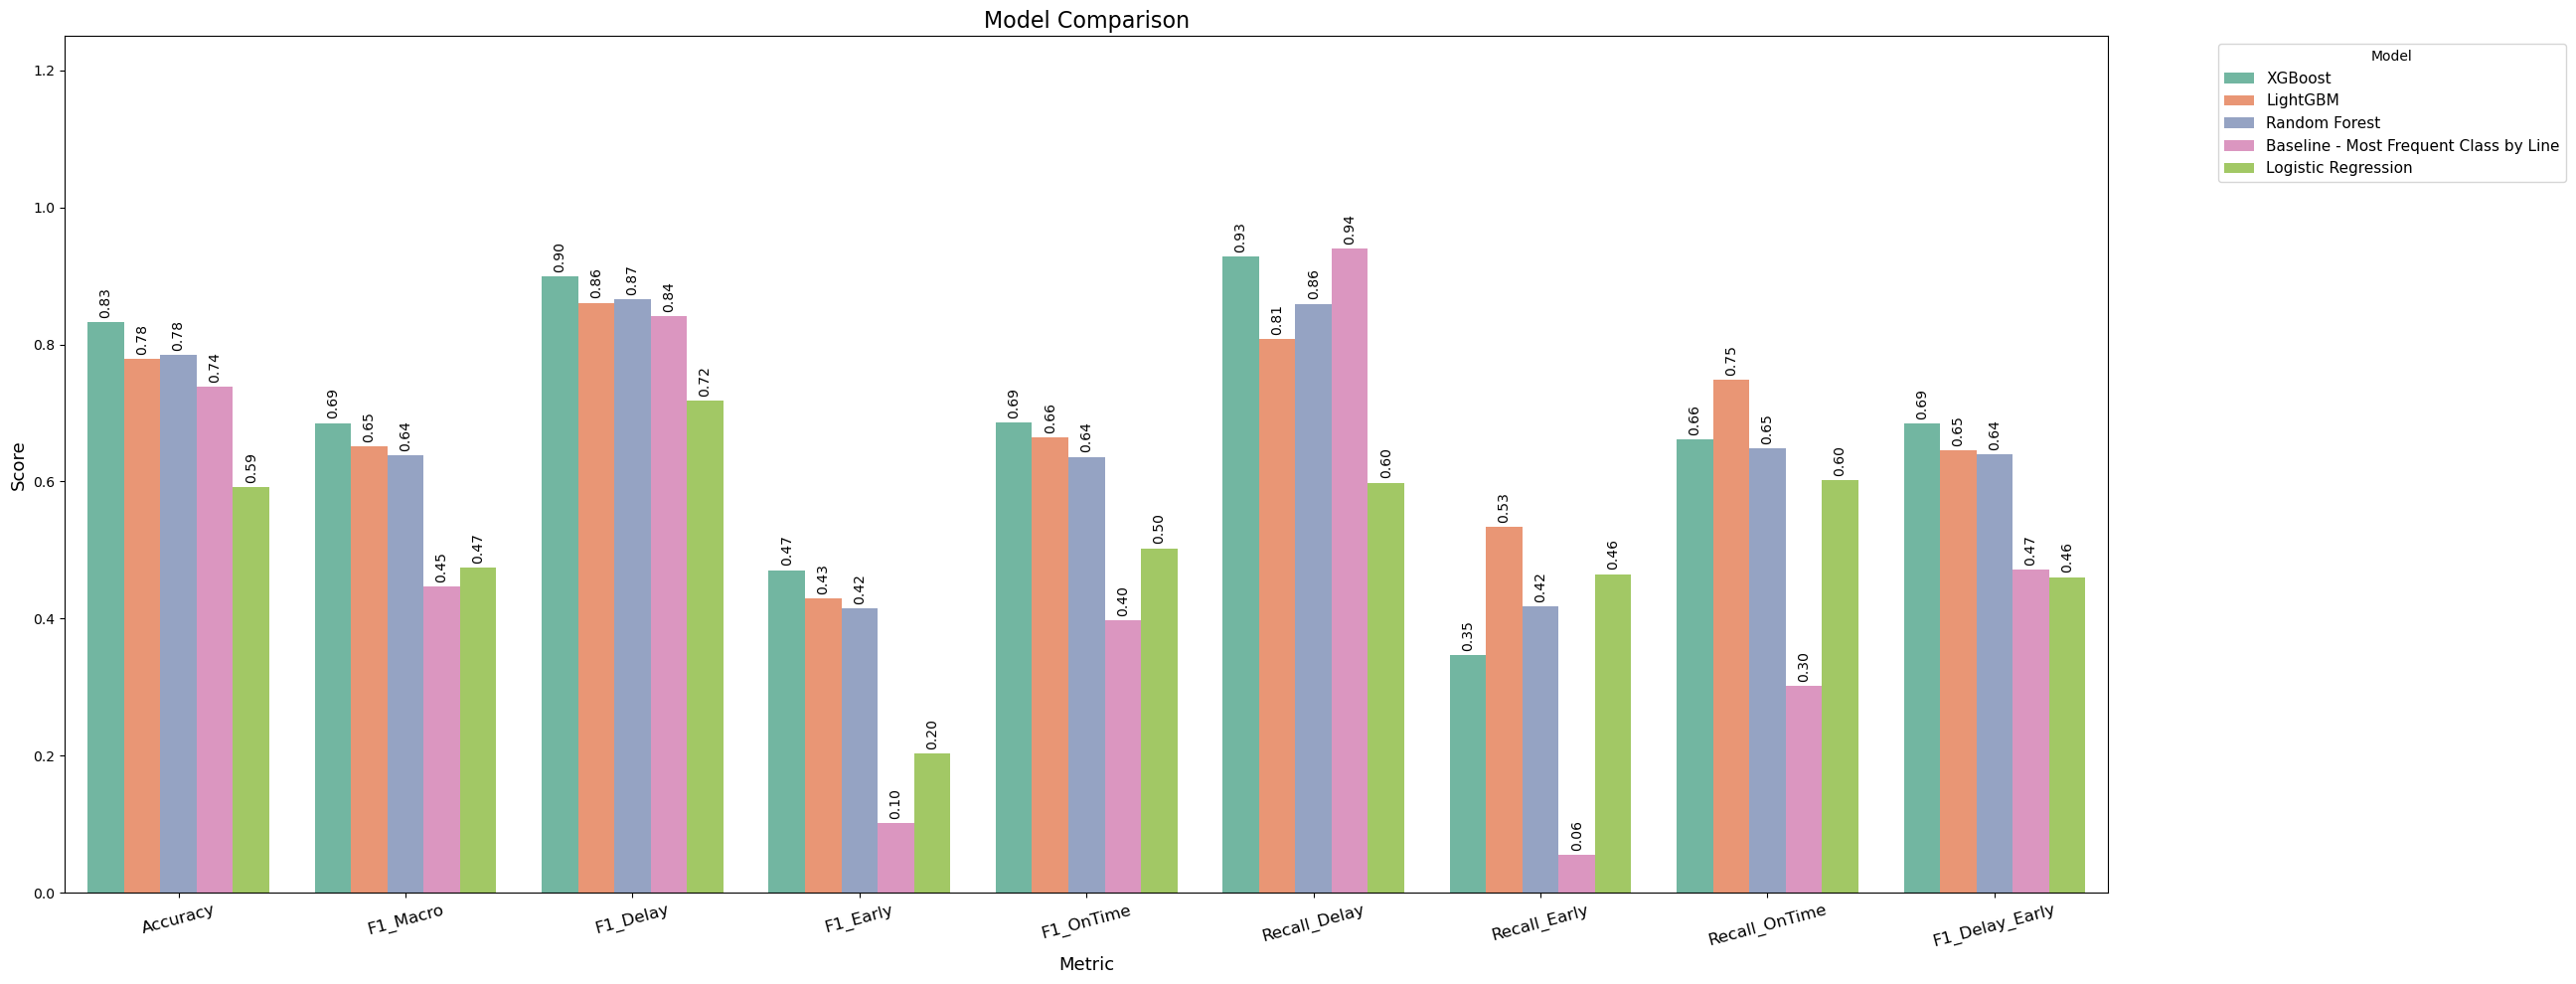

In [35]:
# ===== Plotting models metrics ====

results_df = pd.DataFrame(results).sort_values(by='F1_Delay_Early', ascending=False)

metrics = ['Accuracy', 'F1_Macro', 'F1_Delay', 'F1_Early', 'F1_OnTime',
           'Recall_Delay', 'Recall_Early', 'Recall_OnTime', 'F1_Delay_Early']

plot_df = results_df[['Model'] + metrics].melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(26, 10))
ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='Set2')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, rotation=90, padding=3)

plt.title('Model Comparison', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.ylim(0, 1.25)
plt.xticks(rotation=15, fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

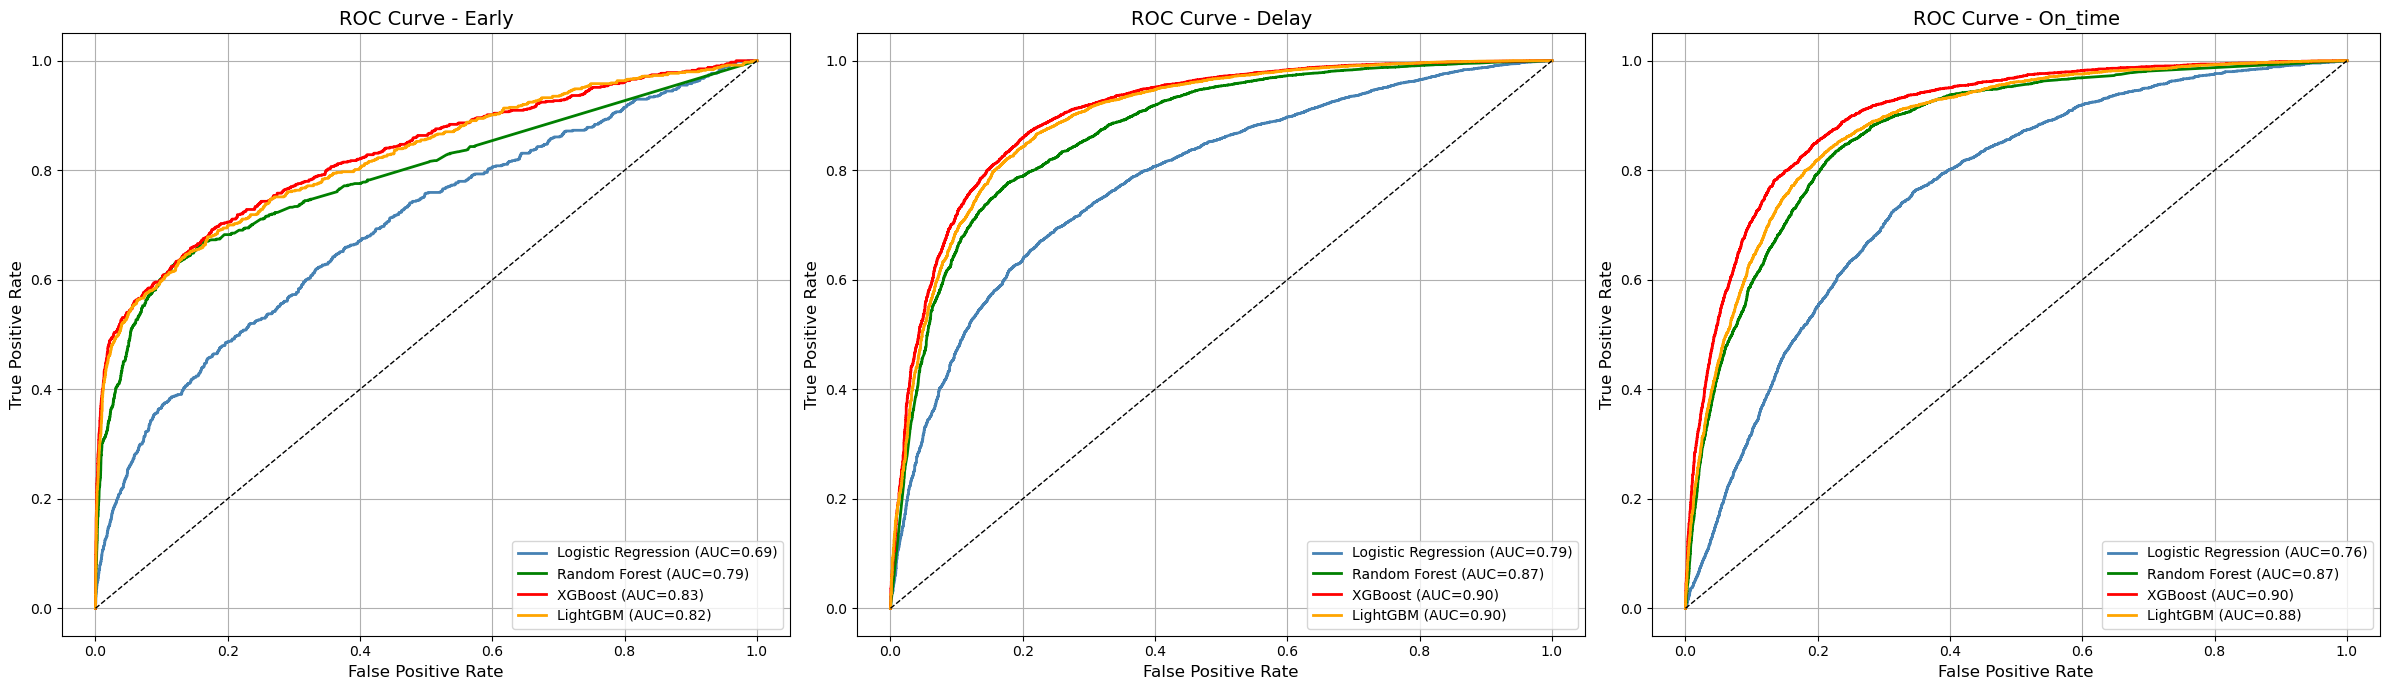

In [13]:
# ===== Models ROC performance ====

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = ['delay', 'early', 'on_time']
y_val_bin = label_binarize(y_val, classes=classes)

models_proba = {
    'Logistic Regression': lr.predict_proba(X_val),
    'Random Forest':       rf.predict_proba(X_val),
    'XGBoost':             xgb.predict_proba(X_val),
    'LightGBM':            lgbm.predict_proba(X_val)
}

colors = {'Logistic Regression': 'steelblue', 
          'Random Forest': 'green', 
          'XGBoost': 'red', 
          'LightGBM': 'orange'}

for ax, target_class in zip(axes, ['early', 'delay', 'on_time']):
    class_idx = classes.index(target_class)
    
    for model_name, proba in models_proba.items():
        fpr, tpr, _ = roc_curve(y_val_bin[:, class_idx], proba[:, class_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[model_name], linewidth=2,
                label=f'{model_name} (AUC={roc_auc:.2f})')
    
    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(f'ROC Curve - {target_class.capitalize()}', fontsize=14)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True)

plt.tight_layout()
plt.show()

## 6. XGBoost - Selected model

### 6.1. Check Overfitting

- The following analysis compares the XGBoost model performance on both the training and validation datasets.

- The comparison includes Accuracy and Macro F1-score in order to examine the performance gaps between the two datasets.

In [14]:
overfit_results = []
overfit_results.append(check_overfitting(xgb,  X_train, y_train, X_val, y_val, 'XGBoost', le=le))

overfit_df = pd.DataFrame(overfit_results)
print(overfit_df[['Model', 'Train Accuracy', 'Val Accuracy', 'Gap Accuracy', 
                   'Train F1 Macro', 'Val F1 Macro', 'Gap F1 Macro']].round(3))

     Model  Train Accuracy  Val Accuracy  Gap Accuracy  Train F1 Macro  \
0  XGBoost           0.859         0.833         0.026           0.737   

   Val F1 Macro  Gap F1 Macro  
0         0.685         0.052  


In [15]:
result = check_overfitting_full(xgb, X_train, y_train, X_val, y_val, 'XGBoost', le=le)
pd.DataFrame([result]).T

,0
Model,XGBoost
Train Accuracy,0.858667
Val Accuracy,0.832767
Gap Accuracy,0.0259
Train F1 Macro,0.737214
Val F1 Macro,0.685333
Gap F1 Macro,0.051881
Train F1 Early,0.559234
Val F1 Early,0.470696
Gap F1 Early,0.088538


**There is no significant overfitting**

### 6.2. Use SMOTE – Synthetic Minority Over-sampling Technique

To address the class imbalance observed in the training dataset, the SMOTE (Synthetic Minority Oversampling Technique) method was applied.

SMOTE generates synthetic samples for underrepresented classes in the training data, allowing the model to train on a more balanced class distribution. The class distributions before and after applying SMOTE are presented below.

In [16]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
delay_cat
delay      44619
on_time    15266
early       3391
Name: count, dtype: int64

After SMOTE:
delay_cat
delay      44619
early      44619
on_time    44619
Name: count, dtype: int64


=== XGBoost + SMOTE ===
Accuracy:         0.814
F1 Macro:         0.683
F1 Delay:         0.887
F1 Early:         0.482
F1 On Time:       0.681
Recall Delay:     0.875
Recall Early:     0.442
Recall On Time:   0.722

              precision    recall  f1-score   support

       delay       0.90      0.87      0.89      9553
       early       0.53      0.44      0.48       740
     on_time       0.65      0.72      0.68      3251

    accuracy                           0.81     13544
   macro avg       0.69      0.68      0.68     13544
weighted avg       0.82      0.81      0.82     13544



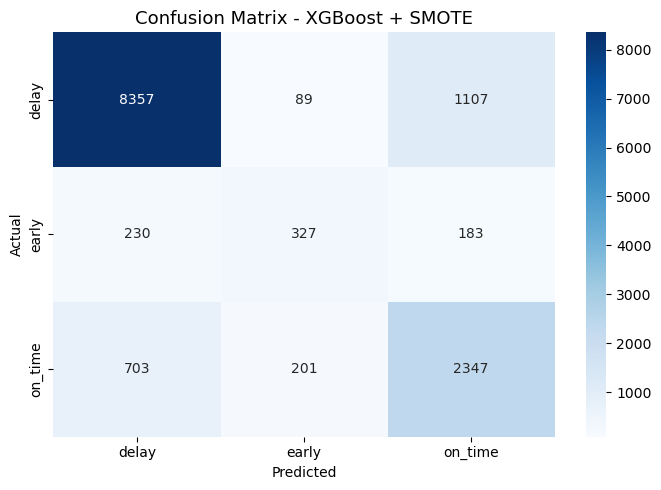

In [17]:
le_sm = LabelEncoder()
y_train_sm_enc = le_sm.fit_transform(y_train_sm)

xgb_sm = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_sm.fit(X_train_sm, y_train_sm_enc)

y_pred_sm = le_sm.inverse_transform(xgb_sm.predict(X_val))
results.append(evaluate_model_pred(y_val, y_pred_sm, 'XGBoost + SMOTE'))

In [23]:
## Bad Rseults

### 6.3. Threshold Tuning

An additional experiment was performed in order to improve the identification of the underrepresented early class.
Instead of using the default class selection based on the highest predicted probability, a custom probability threshold was applied for the early category. If the predicted probability for early exceeded the defined threshold, the observation was classified as early even if it was not the highest-probability class.
This approach aimed to increase the model’s sensitivity to early trips and evaluate the trade-off between recall and overall classification performance.

In [18]:
# Get prediction probabilities
y_proba = xgb.predict_proba(X_val)

# Get index of the 'early' class
early_idx = list(le.classes_).index('early')

# Try lower threshold for 'early'
threshold = 0.2  # instead of 0.33 (default)

y_pred_thresh = []
for proba in y_proba:
    if proba[early_idx] >= threshold:
        y_pred_thresh.append('early')
    else:
        y_pred_thresh.append(le.classes_[np.argmax(proba)])

print(classification_report(y_val, y_pred_thresh))

              precision    recall  f1-score   support

       delay       0.87      0.93      0.90      9553
       early       0.56      0.49      0.52       740
     on_time       0.72      0.62      0.67      3251

    accuracy                           0.83     13544
   macro avg       0.72      0.68      0.70     13544
weighted avg       0.82      0.83      0.82     13544



In [19]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = []
    for proba in y_proba:
        if proba[early_idx] >= thresh:
            y_pred_thresh.append('early')
        else:
            y_pred_thresh.append(le.classes_[np.argmax(proba)])
    
    f1_ear = f1_score(y_val, y_pred_thresh, labels=['early'], average='macro')
    f1_del = f1_score(y_val, y_pred_thresh, labels=['delay'], average='macro')
    acc    = accuracy_score(y_val, y_pred_thresh)
    
    threshold_results.append({
        'Threshold': thresh,
        'Accuracy':  acc,
        'F1_Early':  f1_ear,
        'F1_Delay':  f1_del,
        'F1_Delay_Early': (f1_ear + f1_del) / 2
    })

pd.DataFrame(threshold_results)

,Threshold,Accuracy,F1_Early,F1_Delay,F1_Delay_Early
0,0.10,0.801831,0.425510,0.894058,0.659784
1,0.15,0.819773,0.484425,0.898036,0.691230
2,0.20,0.828854,0.522744,0.899222,0.710983
3,0.25,0.831512,0.522145,0.899548,0.710846
4,0.30,0.832693,0.521457,0.899528,0.710493


**The best Threshold is 0.20**

### 6.4. Hyperparameter Tuning - using Optuna 

In order to further improve the classification performance, a hyperparameter optimization process was performed using the Optuna framework

The optimization focused on tuning the XGBoost model parameters in order to improve the combined performance of the delay and early classes, which were identified as the main modeling challenge in the dataset.

For each trial, Optuna automatically sampled a different set of model parameters, trained the model on the training dataset, and evaluated its performance on the validation dataset using a custom objective function based on the average F1-score of the delay and early classes

In [20]:
# !pip install optuna

import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'eval_metric': 'mlogloss',
        'random_state': 42
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train_enc)
    y_pred = le.inverse_transform(model.predict(X_val))
    
    # אופטימיזציה לפי F1 Delay+Early
    f1_del = f1_score(y_val, y_pred, labels=['delay'], average='macro')
    f1_ear = f1_score(y_val, y_pred, labels=['early'], average='macro')
    return (f1_del + f1_ear) / 2

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best F1 Delay+Early: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-05-12 14:59:37,806] A new study created in memory with name: no-name-65b39116-7af5-492a-8c95-0312d3a09ff2


ERROR! Session/line number was not unique in database. History logging moved to new session 399


[I 2026-05-12 14:59:43,079] Trial 0 finished with value: 0.6889023485981425 and parameters: {'n_estimators': 280, 'max_depth': 8, 'learning_rate': 0.04867081941743936, 'subsample': 0.7464962504806593, 'colsample_bytree': 0.7143194531129275, 'min_child_weight': 2, 'gamma': 0.2949036007292516}. Best is trial 0 with value: 0.6889023485981425.
[I 2026-05-12 14:59:46,610] Trial 1 finished with value: 0.6804779747294142 and parameters: {'n_estimators': 435, 'max_depth': 8, 'learning_rate': 0.12723238619744692, 'subsample': 0.8235560026185735, 'colsample_bytree': 0.6111097145569886, 'min_child_weight': 3, 'gamma': 1.916559845729617}. Best is trial 0 with value: 0.6889023485981425.
[I 2026-05-12 14:59:50,164] Trial 2 finished with value: 0.6858307181917596 and parameters: {'n_estimators': 472, 'max_depth': 7, 'learning_rate': 0.17658689088188087, 'subsample': 0.9676502140348656, 'colsample_bytree': 0.9076723539765156, 'min_child_weight': 2, 'gamma': 0.6560260554831376}. Best is trial 0 with va

Best F1 Delay+Early: 0.6968
Best params: {'n_estimators': 410, 'max_depth': 7, 'learning_rate': 0.11098699725912298, 'subsample': 0.8701996302336686, 'colsample_bytree': 0.9553157013994362, 'min_child_weight': 10, 'gamma': 0.720227657633166}


The best results were of XGBoost + Threshold 0.20 : F1 Delay+Early = 0.703
XGBoost = 0.667
XGBoost + Optuna = 0.672

### 6.5. Check results and overfit for XGBoost + Threshold 0.20

The following analysis evaluates the model performance after applying the custom probability threshold for the early class.

Performance metrics were calculated for both the training and validation datasets in order to compare the impact of the threshold adjustment on model behavior. Special focus was given to the early and delay classes, including their individual F1-scores and their combined average score (F1 D+E).

The comparison also includes the performance gaps between the training and validation datasets after threshold tuning.

In [21]:
# Train predictions with threshold
y_proba_train = xgb.predict_proba(X_train)

y_pred_train_thresh = []
for proba in y_proba_train:
    if proba[early_idx] >= 0.20:
        y_pred_train_thresh.append('early')
    else:
        y_pred_train_thresh.append(le.classes_[np.argmax(proba)])

# Val predictions with threshold
y_pred_val_thresh = []
for proba in y_proba:
    if proba[early_idx] >= 0.20:
        y_pred_val_thresh.append('early')
    else:
        y_pred_val_thresh.append(le.classes_[np.argmax(proba)])

# השוואה
metrics = {
    'Train Accuracy':    accuracy_score(y_train, y_pred_train_thresh),
    'Val Accuracy':      accuracy_score(y_val, y_pred_val_thresh),
    'Train F1 Early':    f1_score(y_train, y_pred_train_thresh, labels=['early'], average='macro'),
    'Val F1 Early':      f1_score(y_val, y_pred_val_thresh, labels=['early'], average='macro'),
    'Train F1 Delay':    f1_score(y_train, y_pred_train_thresh, labels=['delay'], average='macro'),
    'Val F1 Delay':      f1_score(y_val, y_pred_val_thresh, labels=['delay'], average='macro'),
    'Train F1 D+E':      (f1_score(y_train, y_pred_train_thresh, labels=['delay'], average='macro') + 
                          f1_score(y_train, y_pred_train_thresh, labels=['early'], average='macro')) / 2,
    'Val F1 D+E':        (f1_score(y_val, y_pred_val_thresh, labels=['delay'], average='macro') + 
                          f1_score(y_val, y_pred_val_thresh, labels=['early'], average='macro')) / 2,
}

metrics['Gap Accuracy'] = metrics['Train Accuracy'] - metrics['Val Accuracy']
metrics['Gap F1 Early'] = metrics['Train F1 Early'] - metrics['Val F1 Early']
metrics['Gap F1 Delay'] = metrics['Train F1 Delay'] - metrics['Val F1 Delay']
metrics['Gap F1 D+E']   = metrics['Train F1 D+E'] - metrics['Val F1 D+E']

pd.DataFrame([metrics]).T.round(3)

,0
Train Accuracy,0.856
Val Accuracy,0.829
Train F1 Early,0.601
Val F1 Early,0.523
Train F1 Delay,0.915
Val F1 Delay,0.899
Train F1 D+E,0.758
Val F1 D+E,0.711
Gap Accuracy,0.027
Gap F1 Early,0.079


## 7. Check final results on the test

After completing the model development and validation process, the final XGBoost classification model was evaluated on the unseen test dataset.

The evaluation was performed using the selected probability threshold for the early class (0.20), which was previously identified as providing improved balance between the minority classes.

The classification report below summarizes the final model performance on the test dataset across all operational categories.

In [22]:
### Split the test 
target_col = "delay_cat"

X_test = test_df.drop(columns=["delay_cat", "duration_difference_min"], errors="ignore")
y_test = test_df[target_col]

# numeric only
X_test = X_test.select_dtypes(include="number")


y_proba_test = xgb.predict_proba(X_test)

y_pred_test = []
for proba in y_proba_test:
    if proba[early_idx] >= 0.20:
        y_pred_test.append('early')
    else:
        y_pred_test.append(le.classes_[np.argmax(proba)])

print("=== Final Evaluation on Test ===")
print(classification_report(y_test, y_pred_test))

=== Final Evaluation on Test ===
              precision    recall  f1-score   support

       delay       0.88      0.92      0.90      9607
       early       0.51      0.49      0.50       707
     on_time       0.72      0.62      0.67      3259

    accuracy                           0.83     13573
   macro avg       0.70      0.68      0.69     13573
weighted avg       0.82      0.83      0.82     13573



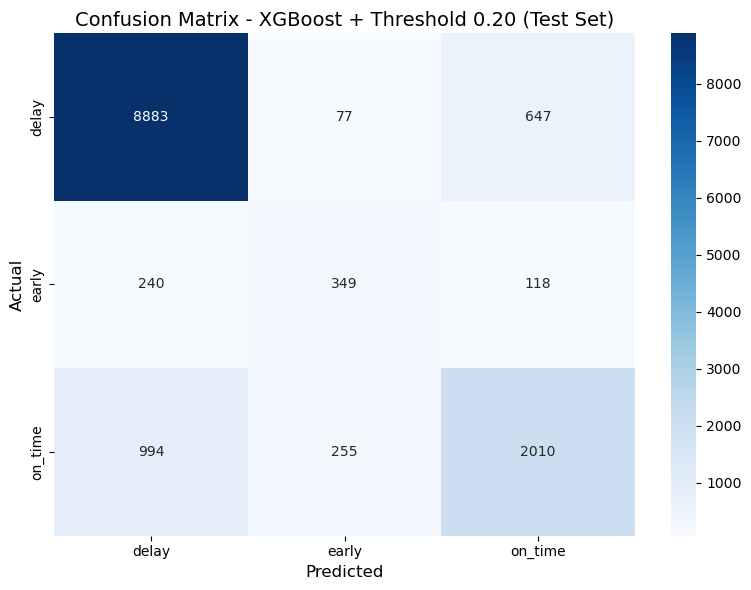

In [23]:
cm = confusion_matrix(y_test, y_pred_test, labels=['delay', 'early', 'on_time'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['delay', 'early', 'on_time'],
            yticklabels=['delay', 'early', 'on_time'])
plt.title('Confusion Matrix - XGBoost + Threshold 0.20 (Test Set)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

### 7.2. Feature importance

A SHAP (SHapley Additive exPlanations) analysis was performed in order to interpret the XGBoost classification model and examine the contribution of the different features to the model predictions.

The SHAP summary plot below presents the overall importance and influence of the features across all prediction classes, allowing identification of the variables that most strongly affect the classification outcomes.

<Figure size 640x480 with 0 Axes>

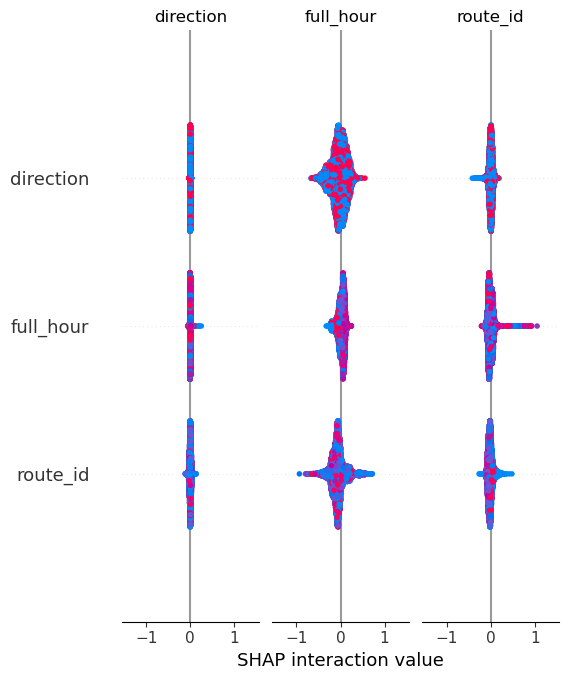

In [24]:
#!pip install shap

import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_val)

# Summary plot for all classes
plt.figure()
shap.summary_plot(shap_values, X_val, class_names=le.classes_, show=True)


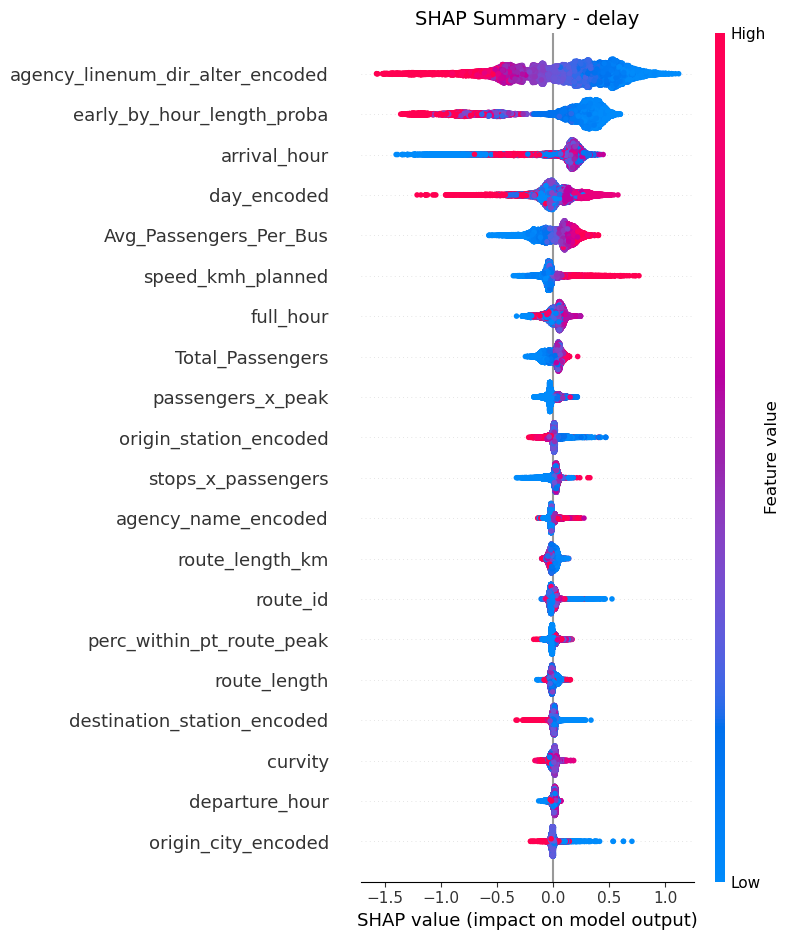

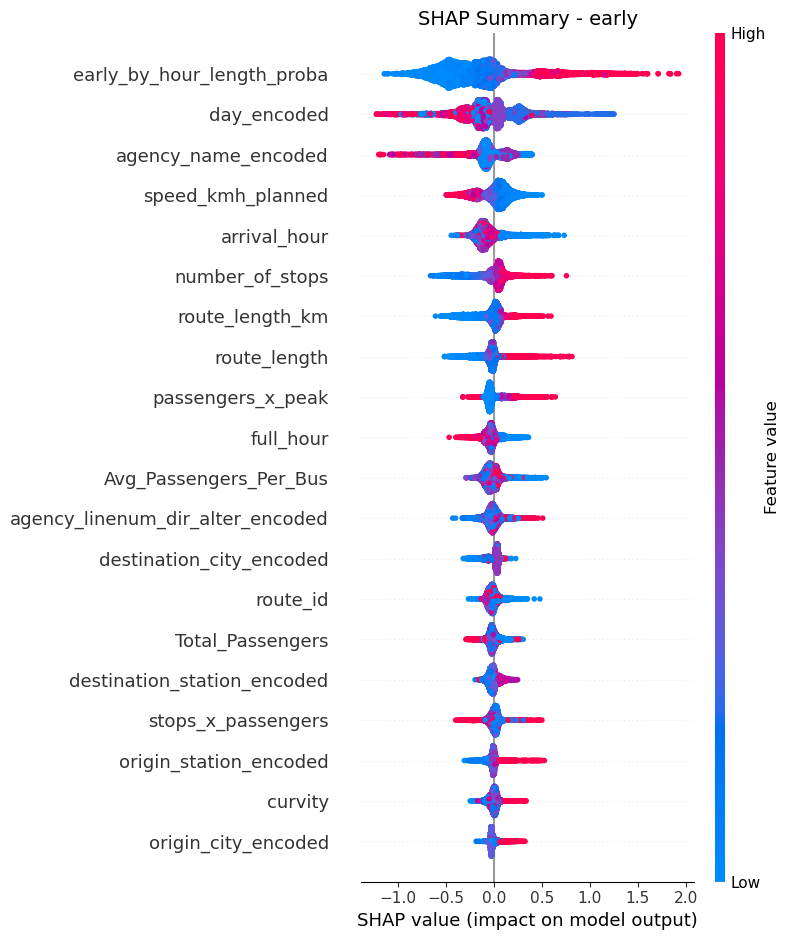

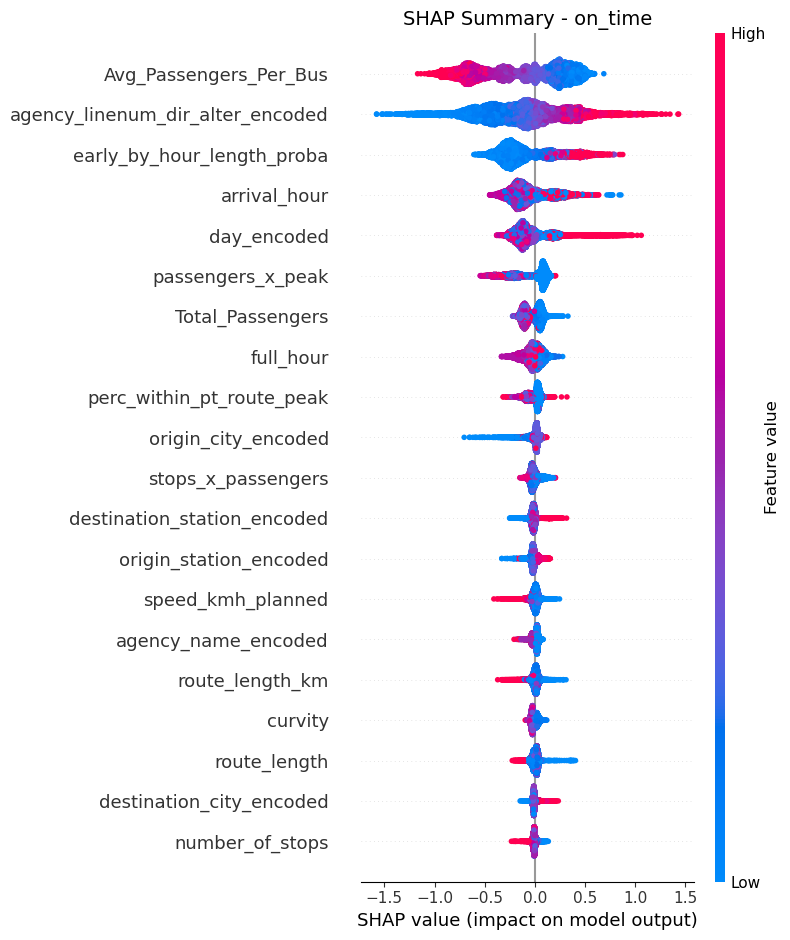

In [25]:
for i, class_name in enumerate(le.classes_):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values[:, :, i],
        X_val,
        feature_names=X_val.columns.tolist(),
        show=False
    )
    plt.title(f'SHAP Summary - {class_name}', fontsize=14)
    plt.tight_layout()
    plt.show()